In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

PROJECT_ROOT = Path.cwd().parent

if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = Path.cwd()

print("Project root:")
print(PROJECT_ROOT)

Project root:
c:\Users\armaa\OneDrive\Desktop\TinyML-Vibration-Anomaly-Detection


In [2]:
RESULTS_DIR = PROJECT_ROOT / "results"
VAAC_DIR = RESULTS_DIR / "vaac_tiny"
BASELINE_DIR = RESULTS_DIR / "baseline_corrected"

print("VAAC results:")
print(VAAC_DIR)

print("\nBaseline results:")
print(BASELINE_DIR)

VAAC results:
c:\Users\armaa\OneDrive\Desktop\TinyML-Vibration-Anomaly-Detection\results\vaac_tiny

Baseline results:
c:\Users\armaa\OneDrive\Desktop\TinyML-Vibration-Anomaly-Detection\results\baseline_corrected


In [3]:
print("VAAC-Tiny result files:")
for file in sorted(VAAC_DIR.glob("*")):
    print(" -", file.name)

print("\nBaseline result files:")
for file in sorted(BASELINE_DIR.glob("*")):
    print(" -", file.name)

VAAC-Tiny result files:
 - figures
 - temporal_consensus_predictions.csv
 - test_predictions.csv
 - training_history.csv
 - vaac_tiny_confusion_matrix.csv
 - vaac_tiny_test_metrics.csv

Baseline result files:
 - baseline_model_comparison.csv
 - logistic_regression_confusion_matrix.csv
 - random_forest_confusion_matrix.csv
 - random_forest_feature_importance.csv
 - svm_confusion_matrix.csv


In [4]:
VAAC_PREDICTIONS = VAAC_DIR / "test_predictions.csv"

vaac_predictions = pd.read_csv(VAAC_PREDICTIONS)

print("Shape:", vaac_predictions.shape)
print("\nColumns:")
print(vaac_predictions.columns.tolist())

display(vaac_predictions.head())

Shape: (136, 15)

Columns:
['recording_id', 'source_file', 'signal_id', 'class', 'window_id', 'start_sample', 'end_sample', 'label', 'predicted_label', 'predicted_class', 'confidence', 'prob_Healthy', 'prob_Ball', 'prob_Inner Race', 'prob_Outer Race']


,recording_id,source_file,signal_id,class,window_id,start_sample,end_sample,label,predicted_label,predicted_class,confidence,prob_Healthy,prob_Ball,prob_Inner Race,prob_Outer Race
0,B007_3_X121,B007_3.mat,X121,Ball,0,0,12000,1,1,Ball,0.995831,0.000002,0.995831,0.004162,0.000006
1,B007_3_X121,B007_3.mat,X121,Ball,1,6000,18000,1,1,Ball,0.994963,0.000002,0.994963,0.005030,0.000005
2,B007_3_X121,B007_3.mat,X121,Ball,2,12000,24000,1,1,Ball,0.994040,0.000002,0.994040,0.005954,0.000004
3,B007_3_X121,B007_3.mat,X121,Ball,3,18000,30000,1,1,Ball,0.996120,0.000002,0.996120,0.003872,0.000006
4,B007_3_X121,B007_3.mat,X121,Ball,4,24000,36000,1,1,Ball,0.995702,0.000002,0.995702,0.004291,0.000006


In [5]:
print(vaac_predictions.columns.tolist())

['recording_id', 'source_file', 'signal_id', 'class', 'window_id', 'start_sample', 'end_sample', 'label', 'predicted_label', 'predicted_class', 'confidence', 'prob_Healthy', 'prob_Ball', 'prob_Inner Race', 'prob_Outer Race']


In [6]:
# Step 222.7 — Calculate Final VAAC-Tiny Classification Metrics

y_true = vaac_predictions["label"].values
y_pred = vaac_predictions["predicted_label"].values

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)
recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)
f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

print("VAAC-Tiny Final Test Performance")
print("=" * 45)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

VAAC-Tiny Final Test Performance
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-score  : 1.0000


In [7]:
# Step 222.8 — Class-wise Performance Report

CLASS_NAMES = [
    "Healthy",
    "Ball",
    "Inner Race",
    "Outer Race"
]

print("VAAC-Tiny Class-wise Performance")
print("=" * 50)

report = classification_report(
    y_true,
    y_pred,
    labels=[0, 1, 2, 3],
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0
)

print(report)

VAAC-Tiny Class-wise Performance
              precision    recall  f1-score   support

     Healthy     1.0000    1.0000    1.0000        79
        Ball     1.0000    1.0000    1.0000        19
  Inner Race     1.0000    1.0000    1.0000        19
  Outer Race     1.0000    1.0000    1.0000        19

    accuracy                         1.0000       136
   macro avg     1.0000    1.0000    1.0000       136
weighted avg     1.0000    1.0000    1.0000       136



In [8]:
# Step 222.9 — Confusion Matrix

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1, 2, 3]
)

print("VAAC-Tiny Confusion Matrix")
print("=" * 40)
print(cm)

VAAC-Tiny Confusion Matrix
[[79  0  0  0]
 [ 0 19  0  0]
 [ 0  0 19  0]
 [ 0  0  0 19]]


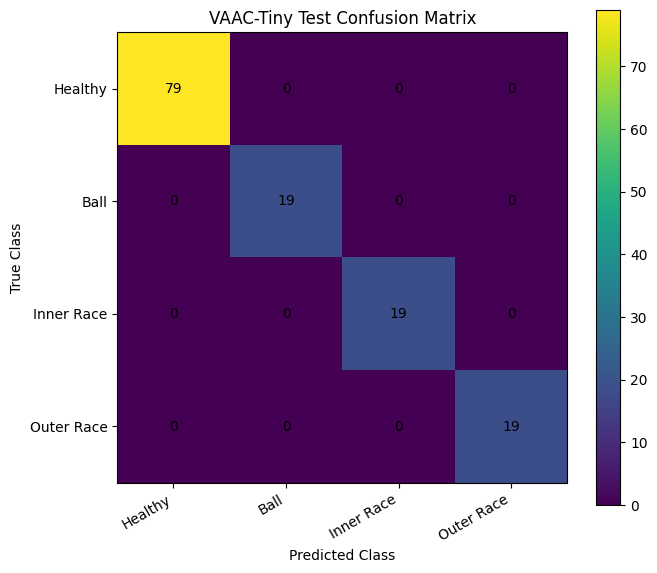

In [9]:
# Step 222.10 — Plot Confusion Matrix

fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(cm)

ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_yticks(range(len(CLASS_NAMES)))

ax.set_xticklabels(
    CLASS_NAMES,
    rotation=30,
    ha="right"
)

ax.set_yticklabels(CLASS_NAMES)

ax.set_xlabel("Predicted Class")
ax.set_ylabel("True Class")
ax.set_title("VAAC-Tiny Test Confusion Matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

In [10]:
# Step 222.11 — Prediction Confidence Analysis

confidence = vaac_predictions["confidence"].values

print("VAAC-Tiny Prediction Confidence Analysis")
print("=" * 50)

print(f"Mean confidence   : {np.mean(confidence):.6f}")
print(f"Median confidence : {np.median(confidence):.6f}")
print(f"Minimum confidence: {np.min(confidence):.6f}")
print(f"Maximum confidence: {np.max(confidence):.6f}")
print(f"Std. deviation    : {np.std(confidence):.6f}")

VAAC-Tiny Prediction Confidence Analysis
Mean confidence   : 0.997570
Median confidence : 0.999991
Minimum confidence: 0.982192
Maximum confidence: 0.999997
Std. deviation    : 0.004204


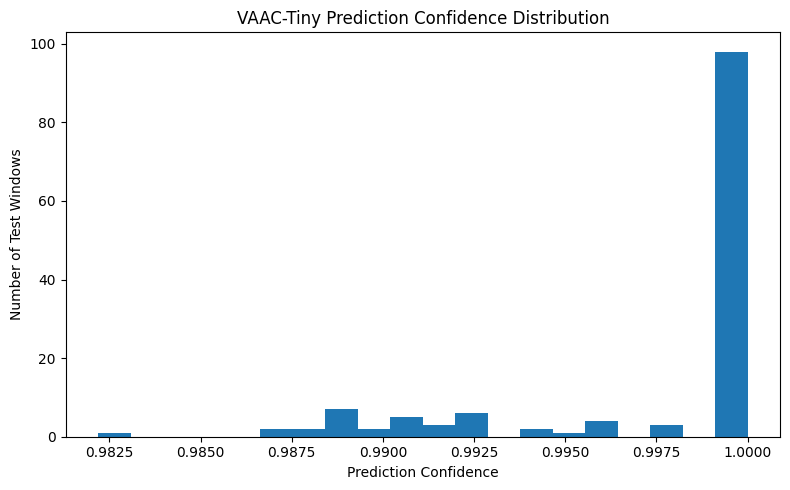

In [11]:
# Step 222.12 — Plot Prediction Confidence Distribution

plt.figure(figsize=(8, 5))

plt.hist(
    confidence,
    bins=20
)

plt.xlabel("Prediction Confidence")
plt.ylabel("Number of Test Windows")
plt.title("VAAC-Tiny Prediction Confidence Distribution")

plt.tight_layout()
plt.show()

In [12]:
# Step 222.13 — Incorrect Prediction Analysis

errors = vaac_predictions[
    vaac_predictions["label"] != vaac_predictions["predicted_label"]
]

print("Prediction Error Analysis")
print("=" * 40)

print(f"Total test windows : {len(vaac_predictions)}")
print(f"Incorrect windows  : {len(errors)}")
print(f"Correct windows    : {len(vaac_predictions) - len(errors)}")

if len(errors) > 0:
    print("\nIncorrect predictions:")
    display(errors)
else:
    print("\nNo incorrect test-window predictions.")

Prediction Error Analysis
Total test windows : 136
Incorrect windows  : 0
Correct windows    : 136

No incorrect test-window predictions.


In [13]:
# Step 222.14 — Correct / Incorrect Prediction Summary

correct = np.sum(
    vaac_predictions["label"].values ==
    vaac_predictions["predicted_label"].values
)

incorrect = np.sum(
    vaac_predictions["label"].values !=
    vaac_predictions["predicted_label"].values
)

total = len(vaac_predictions)

print("VAAC-Tiny Prediction Summary")
print("=" * 45)

print(f"Total test windows     : {total}")
print(f"Correct predictions    : {correct}")
print(f"Incorrect predictions  : {incorrect}")

print(f"\nAccuracy calculated     : {correct / total:.4f}")

VAAC-Tiny Prediction Summary
Total test windows     : 136
Correct predictions    : 136
Incorrect predictions  : 0

Accuracy calculated     : 1.0000


In [14]:
# Step 222.15 — Test Class Distribution

class_distribution = (
    vaac_predictions
    .groupby("label")
    .size()
    .reindex([0, 1, 2, 3], fill_value=0)
)

distribution_df = pd.DataFrame({
    "Class": CLASS_NAMES,
    "Number_of_Test_Windows": class_distribution.values
})

display(distribution_df)

print("Total:", distribution_df["Number_of_Test_Windows"].sum())

,Class,Number_of_Test_Windows
0,Healthy,79
1,Ball,19
2,Inner Race,19
3,Outer Race,19


Total: 136


In [15]:
# Step 222.16 — Final VAAC-Tiny Analysis Summary

final_summary = pd.DataFrame({
    "Metric": [
        "Test Windows",
        "Correct Predictions",
        "Incorrect Predictions",
        "Accuracy",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1-Score",
        "Mean Confidence",
        "Minimum Confidence",
        "Maximum Confidence"
    ],
    "Value": [
        total,
        correct,
        incorrect,
        accuracy,
        precision,
        recall,
        f1,
        np.mean(confidence),
        np.min(confidence),
        np.max(confidence)
    ]
})

display(final_summary)


,Metric,Value
0,Test Windows,136.000000
1,Correct Predictions,136.000000
2,Incorrect Predictions,0.000000
3,Accuracy,1.000000
4,Weighted Precision,1.000000
5,Weighted Recall,1.000000
6,Weighted F1-Score,1.000000
7,Mean Confidence,0.997570
8,Minimum Confidence,0.982192
9,Maximum Confidence,0.999997


In [16]:
# Step 222.17 — Save Final Analysis Summary

analysis_dir = RESULTS_DIR / "final_analysis"
analysis_dir.mkdir(parents=True, exist_ok=True)

summary_file = analysis_dir / "vaac_tiny_final_analysis_summary.csv"

final_summary.to_csv(
    summary_file,
    index=False
)

print("Final analysis summary saved:")
print(summary_file)

Final analysis summary saved:
c:\Users\armaa\OneDrive\Desktop\TinyML-Vibration-Anomaly-Detection\results\final_analysis\vaac_tiny_final_analysis_summary.csv


In [17]:
# Step 222.18 — Final Step 222 Verification

print("=" * 60)
print("STEP 222 — FINAL VAAC-TINY ANALYSIS")
print("=" * 60)

print(f"Test samples       : {total}")
print(f"Correct predictions: {correct}")
print(f"Incorrect predictions: {incorrect}")

print("\nPerformance:")
print(f"Accuracy            : {accuracy:.4f}")
print(f"Precision           : {precision:.4f}")
print(f"Recall              : {recall:.4f}")
print(f"F1-score            : {f1:.4f}")

print("\nConfidence:")
print(f"Mean                : {np.mean(confidence):.6f}")
print(f"Minimum             : {np.min(confidence):.6f}")
print(f"Maximum             : {np.max(confidence):.6f}")

print("\nConfusion Matrix:")
print(cm)

print("\nStep 222 completed successfully.")

STEP 222 — FINAL VAAC-TINY ANALYSIS
Test samples       : 136
Correct predictions: 136
Incorrect predictions: 0

Performance:
Accuracy            : 1.0000
Precision           : 1.0000
Recall              : 1.0000
F1-score            : 1.0000

Confidence:
Mean                : 0.997570
Minimum             : 0.982192
Maximum             : 0.999997

Confusion Matrix:
[[79  0  0  0]
 [ 0 19  0  0]
 [ 0  0 19  0]
 [ 0  0  0 19]]

Step 222 completed successfully.
